<a href="https://colab.research.google.com/github/Overlord15/Deep-Learning-Lab-IA1/blob/main/DeepLearningLab_CIFAR10_Completed_Mobilenet_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

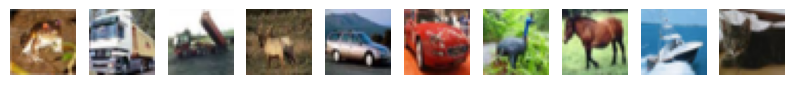

In [16]:
#Step 0: Visualise the Dataset

import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10

(X_train, y_train), (_, _) = cifar10.load_data()

plt.figure(figsize=(10, 2))

for i in range(10):

    plt.subplot(1, 10, i+1)

    plt.imshow(X_train[i])

    plt.axis('off')

plt.show()

In [17]:
#step 1- Load in CIFAR-10

import tensorflow as tf

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.applications.densenet import preprocess_input

from tensorflow.keras.utils import to_categorical

#load in CIFAR-10

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [18]:
#step 2.1 - (fix) Resize for MobileNetV2 (224x224)

#fix: resize images one batch at a time using tf.data for memory efficiency

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

#from tensorflow.keras.applications.resnet50 import preprocess_input

#from tensorflow.keras.applications.vgg16 import preprocess_input

#from tensorflow.keras.applications.densenet import preprocess_input

BATCH_SIZE = 32

IMG_SIZE = (224, 224)

#preprocessing function for map

def preprocess(image, label):

    image = tf.image.resize(image, IMG_SIZE)

    image = preprocess_input(image)  # scale to [-1, 1]

    return image, tf.one_hot(label[0], 10)

#train dataset

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#test dataset

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#from tensorflow.keras.applications.densenet import DenseNet121

#load MobileNetV2 base model

# base_model_densenet121 = DenseNet121(weights='imagenet',

#                          include_top=False, #without top classification head

#                          input_shape=(224, 224, 3))

# base_model_densenet121.trainable = False  #going with freezed pretrained layers (for now)

# -----------------------------------------------------------------------
# OTHER MODELS - uncomment the block for the model you want to use.
# Also swap variable names in Steps 4-8:
#   base_model_densenet121  ->  e.g. base_model_mobilenetv2
#   model_densenet121       ->  e.g. model_mobilenetv2
# In step 1, keep only the matching preprocess_input import active.
# -----------------------------------------------------------------------

## --- MobileNetV2 ---
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
base_model_mobilenetv2 = MobileNetV2(weights='imagenet',
                          include_top=False,
                          input_shape=(224, 224, 3))
base_model_mobilenetv2.trainable = False

## --- DenseNet169 ---
#from tensorflow.keras.applications.densenet import DenseNet169
#base_model_densenet169 = DenseNet169(weights='imagenet',
#                          include_top=False,
#                          input_shape=(224, 224, 3))
#base_model_densenet169.trainable = False

## --- DenseNet201 ---
#from tensorflow.keras.applications.densenet import DenseNet201
#base_model_densenet201 = DenseNet201(weights='imagenet',
#                          include_top=False,
#                          input_shape=(224, 224, 3))
#base_model_densenet201.trainable = False

## --- ResNet50 ---
#from tensorflow.keras.applications.resnet50 import ResNet50
#base_model_resnet50 = ResNet50(weights='imagenet',
#                    include_top=False,
#                    input_shape=(224, 224, 3))
#base_model_resnet50.trainable = False

## --- ResNet152 ---
#from tensorflow.keras.applications.resnet import ResNet152
#base_model_resnet152 = ResNet152(weights='imagenet',
#                      include_top=False,
#                      input_shape=(224, 224, 3))
#base_model_resnet152.trainable = False

## --- VGG16 ---
#from tensorflow.keras.applications.vgg16 import VGG16
#base_model_vgg16 = VGG16(weights='imagenet',
#               include_top=False,
#               input_shape=(224, 224, 3))
#base_model_vgg16.trainable = False

## --- VGG19 ---
#from tensorflow.keras.applications.vgg19 import VGG19
#base_model_vgg19 = VGG19(weights='imagenet',
#               include_top=False,
#               input_shape=(224, 224, 3))
#base_model_vgg19.trainable = False

# -----------------------------------------------------------------------

In [19]:
#Step 4 - Adding our custom top classification head

from tensorflow.keras import layers, models

#custom head

model_mobilenetv2 = models.Sequential([

    base_model_mobilenetv2,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')  # 10 classes for CIFAR-10

])

#compile the model

model_mobilenetv2.compile(optimizer='adam',

              loss='categorical_crossentropy',

              metrics=['accuracy'])

In [20]:
#Step 5 - Train

#run fit()

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#optional but helpful callbacks

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

checkpoint = ModelCheckpoint('mobilenetv2_cifar10.h5', save_best_only=True)

#train the model

history = model_mobilenetv2.fit(

    train_ds,

    validation_data=test_ds,

    epochs=10,

    callbacks=[early_stop, checkpoint]

)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6745 - loss: 0.9710

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 97s 49ms/step - accuracy: 0.7455 - loss: 0.7567 - val_accuracy: 0.8349 - val_loss: 0.4865
Epoch 2/10
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7968 - loss: 0.5985

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.8011 - loss: 0.5903 - val_accuracy: 0.8418 - val_loss: 0.4588
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.8127 - loss: 0.5511 - val_accuracy: 0.8391 - val_loss: 0.4615
Epoch 4/10
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8196 - loss: 0.5317

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.8244 - loss: 0.5202 - val_accuracy: 0.8430 - val_loss: 0.4509
Epoch 5/10
1561/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8244 - loss: 0.5136

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 37ms/step - accuracy: 0.8290 - loss: 0.5040 - val_accuracy: 0.8494 - val_loss: 0.4352
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 36ms/step - accuracy: 0.8325 - loss: 0.4896 - val_accuracy: 0.8493 - val_loss: 0.4520
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.8383 - loss: 0.4737 - val_accuracy: 0.8462 - val_loss: 0.4471
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.8392 - loss: 0.4626 - val_accuracy: 0.8502 - val_loss: 0.4472


In [21]:
#Step 6 - run a final performance evaluation (higher the better)

# Q(a) Find the test accuracy for the model.

loss, acc = model_mobilenetv2.evaluate(test_ds, verbose=1)

print(f"Test Accuracy: {acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8494 - loss: 0.4352
Test Accuracy: 0.85


In [22]:
#Step 7 - fine tune MobileNetV2 for higher Accuracy (optional)

# Q(b)Fine-tune the model using user-defined number of epochs. Try 5, 10, 15.

#unfreeze the base model

base_model_mobilenetv2.trainable = True

#recompile with a lower learning rate

model_mobilenetv2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),

              loss='categorical_crossentropy',

              metrics=['accuracy'])

#fine-tune the model

fine_tune_epochs = 5

total_epochs = 10 + fine_tune_epochs

history_fine = model_mobilenetv2.fit(

    train_ds,

    validation_data=test_ds,

    epochs=total_epochs,

    initial_epoch=len(history.epoch),

    callbacks=[early_stop, checkpoint]

)

Epoch 9/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 289s 150ms/step - accuracy: 0.7338 - loss: 0.8258 - val_accuracy: 0.5400 - val_loss: 1.3937
Epoch 10/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 200s 128ms/step - accuracy: 0.8420 - loss: 0.4821 - val_accuracy: 0.8152 - val_loss: 0.5600
Epoch 11/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8756 - loss: 0.3823

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 199s 127ms/step - accuracy: 0.8832 - loss: 0.3560 - val_accuracy: 0.8755 - val_loss: 0.3752
Epoch 12/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9048 - loss: 0.2849

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 203s 128ms/step - accuracy: 0.9116 - loss: 0.2654 - val_accuracy: 0.8997 - val_loss: 0.3050
Epoch 13/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9288 - loss: 0.2137

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 199s 128ms/step - accuracy: 0.9340 - loss: 0.1986 - val_accuracy: 0.9062 - val_loss: 0.2951
Epoch 14/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 127ms/step - accuracy: 0.9523 - loss: 0.1481 - val_accuracy: 0.9103 - val_loss: 0.2995
Epoch 15/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 126ms/step - accuracy: 0.9651 - loss: 0.1105 - val_accuracy: 0.9130 - val_loss: 0.3122


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9062 - loss: 0.2951
Test Accuracy: 0.91


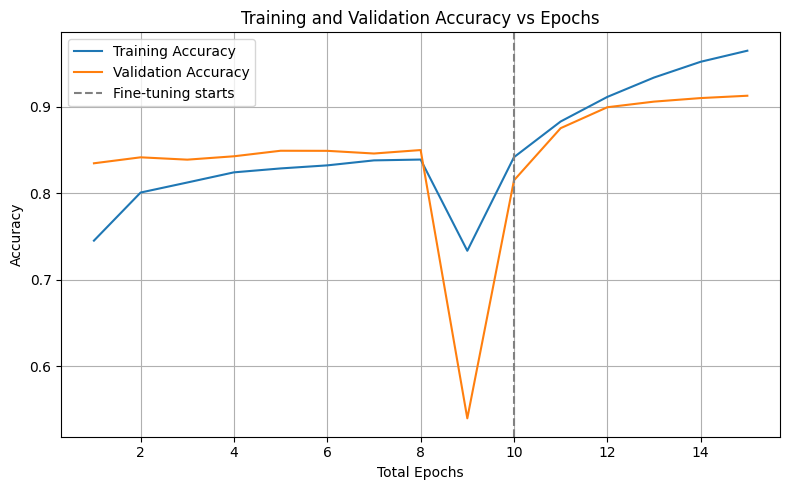

In [23]:
#Step 8 - evaluate again (higher the better)

# Q(c) Find out test accuracy.

loss, acc = model_mobilenetv2.evaluate(test_ds, verbose=1)

print(f"Test Accuracy: {acc:.2f}")

# Q(c) Plot final accuracies (training and validation) vs total epochs

total_acc     = history.history['accuracy']     + history_fine.history['accuracy']
total_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

plt.figure(figsize=(8, 5))
plt.plot(range(1, total_epochs + 1), total_acc,     label='Training Accuracy')
plt.plot(range(1, total_epochs + 1), total_val_acc, label='Validation Accuracy')
plt.axvline(x=10, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training and Validation Accuracy vs Epochs')
plt.xlabel('Total Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()